In [1]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

In [3]:
# ==========================================
# CONFIGURATION
# ==========================================
# TODO: CHANGE THIS to your actual dataset folder path
DATASET_ROOT = "./ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

# BraTS 2023 Naming Convention Suffixes
SUFFIX_MAP = {
    't1': '-t1n.nii.gz',   # T1 Native
    't1ce': '-t1c.nii.gz', # T1 Contrast Enhanced
    't2': '-t2w.nii.gz',   # T2 Weighted
    'flair': '-t2f.nii.gz',# T2 FLAIR
    'seg': '-seg.nii.gz'   # Segmentation Mask
}

In [4]:
def load_patient_volume(patient_id, dataset_path=DATASET_ROOT):
    """
    Loads all 4 modalities and the segmentation mask for a specific patient.
    Returns a dictionary containing the 3D numpy arrays and the affine matrix.
    """
    patient_folder = os.path.join(dataset_path, patient_id)
    
    if not os.path.exists(patient_folder):
        print(f"Error: Patient folder not found at {patient_folder}")
        return None

    data = {}
    affine = None

    # Load MRI modalities
    for modality, suffix in SUFFIX_MAP.items():
        file_path = os.path.join(patient_folder, f"{patient_id}{suffix}")
        
        if os.path.exists(file_path):
            img = nib.load(file_path)
            data[modality] = img.get_fdata()
            if affine is None:
                affine = img.affine
        else:
            print(f"Warning: File missing for {modality} -> {file_path}")
            data[modality] = None

    return data, affine

def visualize_slice(data, slice_idx=None):
    """
    Visualizes the axial slice of all modalities and the segmentation overlay.
    """
    # If no slice provided, pick the middle one
    if slice_idx is None:
        slice_idx = data['t1'].shape[2] // 2

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    
    # 1. T1 Native
    axes[0].imshow(data['t1'][:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[0].set_title('T1 Native')
    axes[0].axis('off')

    # 2. T1 Contrast (T1ce)
    axes[1].imshow(data['t1ce'][:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[1].set_title('T1 Contrast (T1ce)')
    axes[1].axis('off')

    # 3. T2 Weighted
    axes[2].imshow(data['t2'][:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[2].set_title('T2 Weighted')
    axes[2].axis('off')

    # 4. FLAIR
    axes[3].imshow(data['flair'][:, :, slice_idx].T, cmap='gray', origin='lower')
    axes[3].set_title('FLAIR')
    axes[3].axis('off')

    # 5. Segmentation Mask (Overlay)
    # We display FLAIR as background and overlay mask
    axes[4].imshow(data['flair'][:, :, slice_idx].T, cmap='gray', origin='lower')
    
    # Create a custom colormap for the mask: 0=Clear, 1=Red(NCR), 2=Green(ED), 3=Blue(ET)
    mask_slice = data['seg'][:, :, slice_idx].T
    if np.max(mask_slice) > 0:
        # Create a masked array where 0 (background) is transparent
        masked_data = np.ma.masked_where(mask_slice == 0, mask_slice)
        # Using a distinct colormap (e.g., 'jet' or custom)
        axes[4].imshow(masked_data, cmap='spring', alpha=0.6, origin='lower')
    
    axes[4].set_title(f'Segmentation Overlay (Slice {slice_idx})')
    axes[4].axis('off')

    plt.suptitle(f"Visualization: Slice {slice_idx}", fontsize=16)
    plt.tight_layout()
    plt.show()

def analyze_tumor(data):
    """
    Calculates volumes for specific tumor regions following BraTS standards.
    """
    seg = data['seg']
    
    # Voxel volume (BraTS is usually 1mm x 1mm x 1mm = 1mm^3)
    # If not 1mm, we would calculate from affine, but for BraTS it's standard.
    voxel_volume_mm3 = 1.0 

    # Count pixels
    ncr_net_count = np.sum(seg == 1) # Necrotic/Non-enhancing
    edema_count   = np.sum(seg == 2) # Edema
    et_count      = np.sum(seg == 4) # Enhancing Tumor (Label 3 is unused)

    # BraTS Clinical Sub-regions
    # 1. Whole Tumor (WT) = Label 1 + 2 + 4
    wt_vol = (ncr_net_count + edema_count + et_count) * voxel_volume_mm3
    
    # 2. Tumor Core (TC) = Label 1 + 4 (Excludes Edema)
    tc_vol = (ncr_net_count + et_count) * voxel_volume_mm3
    
    # 3. Enhancing Tumor (ET) = Label 4
    et_vol = et_count * voxel_volume_mm3

    print("-" * 30)
    print("TUMOR ANALYSIS REPORT")
    print("-" * 30)
    print(f"Whole Tumor (WT) Volume:   {wt_vol/1000:.2f} ml (cc)")
    print(f"Tumor Core (TC) Volume:    {tc_vol/1000:.2f} ml (cc)")
    print(f"Enhancing Tumor (ET) Vol:  {et_vol/1000:.2f} ml (cc)")
    print("-" * 30)
    print("Raw Voxel Counts:")
    print(f"  - Necrotic (Label 1): {ncr_net_count}")
    print(f"  - Edema    (Label 2): {edema_count}")
    print(f"  - Active   (Label 4): {et_count}")
    print("-" * 30)

Processing Patient: BraTS-GLI-00000-000...
Best slice for visualization (most tumor): 74


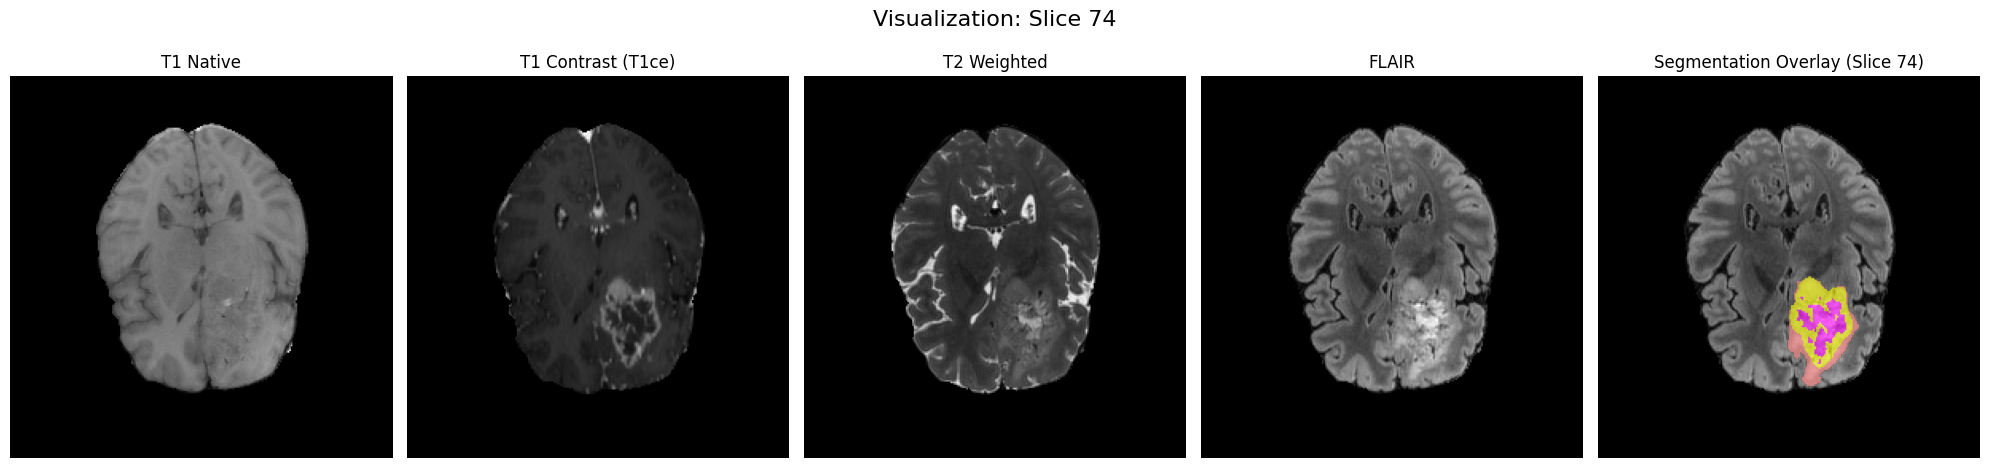

------------------------------
TUMOR ANALYSIS REPORT
------------------------------
Whole Tumor (WT) Volume:   24.57 ml (cc)
Tumor Core (TC) Volume:    11.74 ml (cc)
Enhancing Tumor (ET) Vol:  0.00 ml (cc)
------------------------------
Raw Voxel Counts:
  - Necrotic (Label 1): 11738
  - Edema    (Label 2): 12836
  - Active   (Label 4): 0
------------------------------


In [5]:
# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Find a random patient in the folder
    # Assuming folder structure is Root/BraTS-GLI-XXXXX-000/
    try:
        subfolders = [f for f in os.listdir(DATASET_ROOT) if os.path.isdir(os.path.join(DATASET_ROOT, f))]
        subfolders.sort()
        
        if not subfolders:
            print("No patient folders found. Check your DATASET_ROOT path.")
        else:
            # Let's pick the first patient found
            sample_patient_id = subfolders[0] 
            print(f"Processing Patient: {sample_patient_id}...")

            # 2. Load Data
            patient_data, affine_mat = load_patient_volume(sample_patient_id)

            if patient_data['t1'] is not None:
                # 3. Find the slice with the largest tumor area automatically
                # (So we don't visualize a blank black slice)
                seg_volume = patient_data['seg']
                # Sum along axes 0 and 1 to find which z-slice has most tumor pixels
                tumor_counts_per_slice = np.sum(seg_volume > 0, axis=(0, 1))
                best_slice = np.argmax(tumor_counts_per_slice)
                
                print(f"Best slice for visualization (most tumor): {best_slice}")

                # 4. Visualize
                visualize_slice(patient_data, slice_idx=best_slice)

                # 5. Analyze
                analyze_tumor(patient_data)

    except Exception as e:
        print(f"An error occurred: {e}")
        print("Tip: Ensure DATASET_ROOT points to the parent folder containing the patient subfolders.")